# BreastDivider dataset - wstepne rozpoznanie

Notebook podsumowujący Etap 1 pracowni problemowej - lokalne pobranie malej probki BreastDivider, sprawdzenie struktury plikow, podstawowe EDA plikow NIfTI oraz wizualizacje obrazow MRI z maskami lewej i prawej piersi.

Notebook nie zawiera treningu modelu, lecz rozpoznanie techniczne datasetu i stwierdzenie czy nadaje się do przygotowania pipeline'u slice-level dla dalszej pracy nad embeddingami i virtual DCE.

## 1. Kontekst

BreastDivider jest publicznym datasetem MRI piersi z maskami segmentacji lewej i prawej piersi. W kontekscie pracy _Breast MRI Embedding Models for Virtual Dynamic Contrast-Enhanced Image Synthesis_ dataset jest istotny przede wszystkim jako zrodlo danych i masek anatomicznych.

Maski left/right moga zostac wykorzystane do:

- wyboru przekrojow zawierajacych tkanke piersi,
- ograniczenia analizy do obszaru piersi,
- cropowania lub maskowania obrazu,
- odrzucania pustych lub malo informacyjnych slice'ow,
- pozniejszej ewaluacji rekonstrukcji w masce piersi.

In [1]:
from pathlib import Path
import re

import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'BreastDividerDataset'
OUT_DIR = ROOT / 'outputs' / 'breastdivider_eda'
VIS_DIR = OUT_DIR / 'visualizations'

print('ROOT:', ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), DATA_DIR)
print('OUT_DIR exists:', OUT_DIR.exists(), OUT_DIR)
print('VIS_DIR exists:', VIS_DIR.exists(), VIS_DIR)

ROOT: C:\Users\MiłoszAndruczyk\Documents\BreastMRI_Embedding_Models_for_vDCE
DATA_DIR exists: True C:\Users\MiłoszAndruczyk\Documents\BreastMRI_Embedding_Models_for_vDCE\data\BreastDividerDataset
OUT_DIR exists: True C:\Users\MiłoszAndruczyk\Documents\BreastMRI_Embedding_Models_for_vDCE\outputs\breastdivider_eda
VIS_DIR exists: True C:\Users\MiłoszAndruczyk\Documents\BreastMRI_Embedding_Models_for_vDCE\outputs\breastdivider_eda\visualizations


## 2. Pliki wynikowe wygenerowane w Etapie 1

W Etapie 1 wykorzystano trzy skrypty:

- `inspect_breastdivider_structure.py` - inwentaryzacja pobranych plikow,
- `eda_nifti_summary.py` - podstawowe statystyki wolumenow NIfTI,
- `visualize_breastdivider_sample.py` - wizualizacja MRI + maska left/right.

Ponizsza komorka wczytuje wygenerowane pliki CSV.

In [2]:
file_inventory_path = OUT_DIR / 'file_inventory.csv'
nifti_summary_path = OUT_DIR / 'nifti_summary.csv'
visual_summary_path = OUT_DIR / 'sample_visual_summary.csv'
metadata_summary_path = OUT_DIR / 'metadata_summary.txt'

file_inventory = pd.read_csv(file_inventory_path)
nifti_summary = pd.read_csv(nifti_summary_path)
visual_summary = pd.read_csv(visual_summary_path)

print('file_inventory rows:', len(file_inventory))
print('nifti_summary rows:', len(nifti_summary))
print('visual_summary rows:', len(visual_summary))

if metadata_summary_path.exists():
    print('\nmetadata_summary.txt:')
    print(metadata_summary_path.read_text(encoding='utf-8'))

file_inventory rows: 50
nifti_summary rows: 19
visual_summary rows: 9

metadata_summary.txt:
Mapping rows: 17956
Mapping columns: ['BreastDivider_id', 'id']
Inferred ID column: BreastDivider_id
Inferred original ID column: None
Inferred source column: None
Inferred modality/phase column: None

Classification rows: 3020
Classification columns: ['id', 'healthy', 'malignant', 'benign', 'side']



## 3. Co zostalo pobrane?

Pobrano metadane datasetu oraz mala probke obrazow i masek. W tej probce celem jest sprawdzenie poprawnosci formatu, parowania obraz-maska i podstawowej uzytecznosci masek, a nie analiza statystyczna calego datasetu.

In [3]:
inventory_no_cache = file_inventory[~file_inventory['relative_path'].str.startswith('.cache/')].copy()

display(inventory_no_cache.groupby('kind').agg(files=('relative_path', 'count'), total_mb=('size_bytes', lambda s: round(s.sum() / 1024**2, 2))).reset_index())

display(inventory_no_cache[['relative_path', 'kind', 'size_bytes']])

,kind,files,total_mb
0,csv,1,1.28
1,image,9,217.99
2,json,1,0.00
3,left_right_mask,10,1.33
4,lesion_annotation,1,0.11
5,other,2,0.01


,relative_path,kind,size_bytes
0,breastdivider_id_mapping.csv,csv,1342975
1,dataset.json,json,594
2,mapping_info.txt,other,190
3,README.md,other,9445
4,imagesTr_batch1/BreastDivider_00002_0000.nii.gz,image,21341728
5,imagesTr_batch1/BreastDivider_00003_0000.nii.gz,image,22280067
6,imagesTr_batch1/BreastDivider_00004_0000.nii.gz,image,21340188
7,imagesTr_batch1/BreastDivider_00005_0000.nii.gz,image,53711403
8,imagesTr_batch1/BreastDivider_00006_0000.nii.gz,image,24554161
9,imagesTr_batch1/BreastDivider_00007_0000.nii.gz,image,20589298


In [4]:
image_re = re.compile(r'imagesTr_batch\d+/BreastDivider_(\d{5})_0000\.nii\.gz$')
mask_re = re.compile(r'labelsTr_batch\d+/BreastDivider_(\d{5})\.nii\.gz$')

image_ids = set()
mask_ids = set()

for rel_path in inventory_no_cache['relative_path']:
    image_match = image_re.search(rel_path)
    mask_match = mask_re.search(rel_path)
    if image_match:
        image_ids.add(image_match.group(1))
    if mask_match:
        mask_ids.add(mask_match.group(1))

paired_ids = sorted(image_ids & mask_ids)
missing_images = sorted(mask_ids - image_ids)
missing_masks = sorted(image_ids - mask_ids)

print('Images:', len(image_ids), sorted(image_ids))
print('Masks:', len(mask_ids), sorted(mask_ids))
print('Complete image-mask pairs:', len(paired_ids), paired_ids)
print('Masks without image:', missing_images)
print('Images without mask:', missing_masks)

Images: 9 ['00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010']
Masks: 10 ['00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010']
Complete image-mask pairs: 9 ['00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010']
Masks without image: ['00001']
Images without mask: []


## 4. Podstawowe statystyki NIfTI

Ta sekcja pokazuje, czy pliki `.nii.gz` otwieraja sie poprawnie oraz jakie maja rozmiary, spacing, typ danych i zakresy intensywnosci. Jest to wazne, poniewaz preprocessing slice-level nie moze zakladac jednego stalego ksztaltu lub jednego zakresu intensywnosci.

In [5]:
display(nifti_summary)

errors = nifti_summary[nifti_summary.get('error', pd.Series([''] * len(nifti_summary))).notna() & (nifti_summary.get('error', '') != '')]
print('Rows with loading errors:', len(errors))
if len(errors):
    display(errors[['relative_path', 'error']])

,relative_path,kind,shape,zooms,dtype,min,p01,mean,p99,max,error
0,imagesTr_batch1/BreastDivider_00002_0000.nii.gz,image,448x448x120,0.625x0.625x1.1,uint16,0.0,1.000000,30.219451,138.000000,421.0,NaN
1,imagesTr_batch1/BreastDivider_00003_0000.nii.gz,image,512x512x116,0.7813x0.7813x2,int16,-51.0,0.000000,73.686459,448.000000,1178.0,NaN
2,imagesTr_batch1/BreastDivider_00004_0000.nii.gz,image,512x512x116,0.625x0.625x2,int16,-101.0,-101.000000,73.484535,496.000000,1275.0,NaN
3,imagesTr_batch1/BreastDivider_00005_0000.nii.gz,image,512x512x192,0.6836x0.6836x1.1,int16,0.0,0.000000,222.234450,1721.000000,3063.0,NaN
4,imagesTr_batch1/BreastDivider_00006_0000.nii.gz,image,512x512x116,0.6641x0.6641x1.98618,float32,-37.0,-0.007522,57.098934,442.997131,1225.0,NaN
5,imagesTr_batch1/BreastDivider_00007_0000.nii.gz,image,512x512x116,0.6641x0.6641x2,int16,-72.0,0.000000,55.325967,549.000000,2153.0,NaN
6,imagesTr_batch1/BreastDivider_00008_0000.nii.gz,image,512x512x68,0.625x0.625x3,int16,0.0,0.000000,79.081670,644.000000,1170.0,NaN
7,imagesTr_batch1/BreastDivider_00009_0000.nii.gz,image,512x512x176,0.7031x0.7031x1.1,int16,0.0,0.000000,261.342937,2524.570000,7362.0,NaN
8,imagesTr_batch1/BreastDivider_00010_0000.nii.gz,image,480x160x480,0.691824x1x0.691824,uint16,0.0,0.000000,7.010401,67.000000,312.0,NaN
9,labelsTr_batch1/BreastDivider_00001.nii.gz,left_right_mask,384x384x206,0.833333x0.833333x1.00976,uint8,0.0,0.000000,0.145818,2.000000,2.0,NaN


Rows with loading errors: 0


In [6]:
summary_cols = ['relative_path', 'kind', 'shape', 'zooms', 'dtype', 'min', 'p01', 'mean', 'p99', 'max']
display(nifti_summary[summary_cols])

print('Shapes:')
display(nifti_summary.groupby(['kind', 'shape']).size().reset_index(name='count'))

print('Spacing / zooms:')
display(nifti_summary.groupby(['kind', 'zooms']).size().reset_index(name='count'))

print('Dtypes:')
display(nifti_summary.groupby(['kind', 'dtype']).size().reset_index(name='count'))

,relative_path,kind,shape,zooms,dtype,min,p01,mean,p99,max
0,imagesTr_batch1/BreastDivider_00002_0000.nii.gz,image,448x448x120,0.625x0.625x1.1,uint16,0.0,1.000000,30.219451,138.000000,421.0
1,imagesTr_batch1/BreastDivider_00003_0000.nii.gz,image,512x512x116,0.7813x0.7813x2,int16,-51.0,0.000000,73.686459,448.000000,1178.0
2,imagesTr_batch1/BreastDivider_00004_0000.nii.gz,image,512x512x116,0.625x0.625x2,int16,-101.0,-101.000000,73.484535,496.000000,1275.0
3,imagesTr_batch1/BreastDivider_00005_0000.nii.gz,image,512x512x192,0.6836x0.6836x1.1,int16,0.0,0.000000,222.234450,1721.000000,3063.0
4,imagesTr_batch1/BreastDivider_00006_0000.nii.gz,image,512x512x116,0.6641x0.6641x1.98618,float32,-37.0,-0.007522,57.098934,442.997131,1225.0
5,imagesTr_batch1/BreastDivider_00007_0000.nii.gz,image,512x512x116,0.6641x0.6641x2,int16,-72.0,0.000000,55.325967,549.000000,2153.0
6,imagesTr_batch1/BreastDivider_00008_0000.nii.gz,image,512x512x68,0.625x0.625x3,int16,0.0,0.000000,79.081670,644.000000,1170.0
7,imagesTr_batch1/BreastDivider_00009_0000.nii.gz,image,512x512x176,0.7031x0.7031x1.1,int16,0.0,0.000000,261.342937,2524.570000,7362.0
8,imagesTr_batch1/BreastDivider_00010_0000.nii.gz,image,480x160x480,0.691824x1x0.691824,uint16,0.0,0.000000,7.010401,67.000000,312.0
9,labelsTr_batch1/BreastDivider_00001.nii.gz,left_right_mask,384x384x206,0.833333x0.833333x1.00976,uint8,0.0,0.000000,0.145818,2.000000,2.0


Shapes:


,kind,shape,count
0,image,448x448x120,1
1,image,480x160x480,1
2,image,512x512x116,4
3,image,512x512x176,1
4,image,512x512x192,1
5,image,512x512x68,1
6,left_right_mask,384x384x206,1
7,left_right_mask,448x448x120,1
8,left_right_mask,480x160x480,1
9,left_right_mask,512x512x116,4


Spacing / zooms:


,kind,zooms,count
0,image,0.625x0.625x1.1,1
1,image,0.625x0.625x2,1
2,image,0.625x0.625x3,1
3,image,0.6641x0.6641x1.98618,1
4,image,0.6641x0.6641x2,1
5,image,0.6836x0.6836x1.1,1
6,image,0.691824x1x0.691824,1
7,image,0.7031x0.7031x1.1,1
8,image,0.7813x0.7813x2,1
9,left_right_mask,0.625x0.625x1.1,1


Dtypes:


,kind,dtype,count
0,image,float32,1
1,image,int16,6
2,image,uint16,2
3,left_right_mask,uint8,10


## 5. Zgodnosc obrazow i masek

Dla dalszego pipeline'u kluczowe jest, aby obraz MRI i odpowiadajaca mu maska mialy ten sam rozmiar. W tej probce sparowane przypadki maja zgodne `image_shape` i `mask_shape`.

In [8]:
visual_summary['shape_match'] = visual_summary['image_shape'] == visual_summary['mask_shape']
display(visual_summary[['case_id', 'image_shape', 'mask_shape', 'shape_match', 'selected_axis', 'selected_slice', 'foreground_slices_axis0', 'foreground_slices_axis1', 'foreground_slices_axis2', 'label_counts']])


,case_id,image_shape,mask_shape,shape_match,selected_axis,selected_slice,foreground_slices_axis0,foreground_slices_axis1,foreground_slices_axis2,label_counts
0,2,448x448x120,448x448x120,True,1,230,382,187,115,0:21950962;1:1141895;2:991623
1,3,512x512x116,512x512x116,True,2,34,497,272,115,0:26403758;1:2283076;2:1721870
2,4,512x512x116,512x512x116,True,2,49,444,189,112,0:29130838;1:699083;2:578783
3,5,512x512x192,512x512x192,True,1,219,432,194,168,0:46584309;1:1769025;2:1978314
4,6,512x512x116,512x512x116,True,2,53,477,250,110,0:26830037;1:1889826;2:1688841
5,7,512x512x116,512x512x116,True,1,276,431,193,116,0:28975271;1:719454;2:713979
6,8,512x512x68,512x512x68,True,2,32,426,221,63,0:16386821;1:773982;2:664989
7,9,512x512x176,512x512x176,True,1,264,428,194,174,0:42245244;1:1828347;2:2063753
8,10,480x160x480,480x160x480,True,1,31,465,133,230,0:29897886;1:3754607;2:3211507


## 6. Wizualizacje MRI + maska left/right

Ponizsze obrazy pokazuja wybrane przekroje wolumenow MRI oraz maski lewej i prawej piersi. To najprostszy wizualny test, czy obraz i maska sa poprawnie sparowane oraz czy maska obejmuje anatomicznie sensowny obszar.

PNG visualizations: 9


### BreastDivider_00002_overlay.png

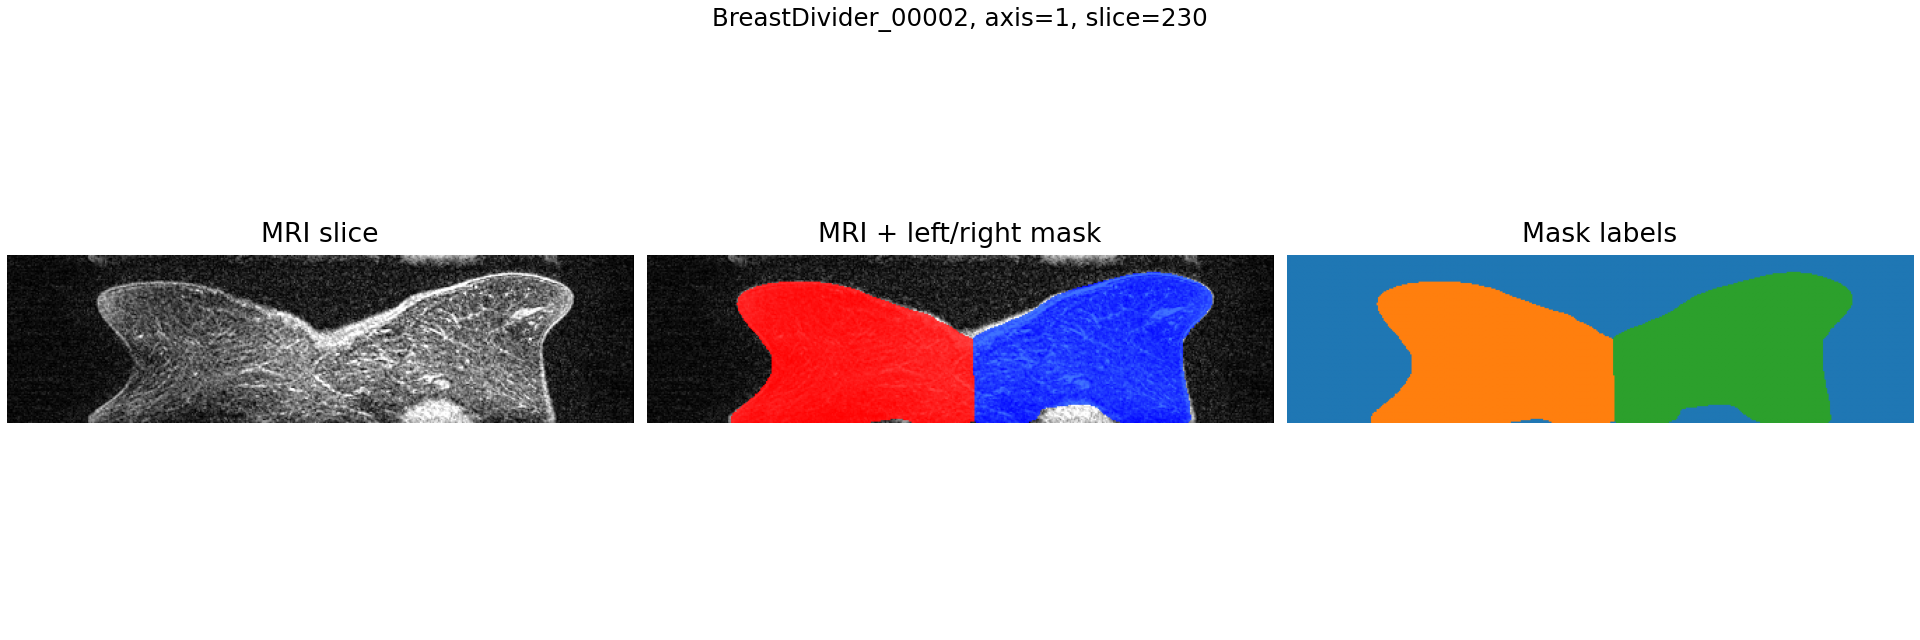

### BreastDivider_00003_overlay.png

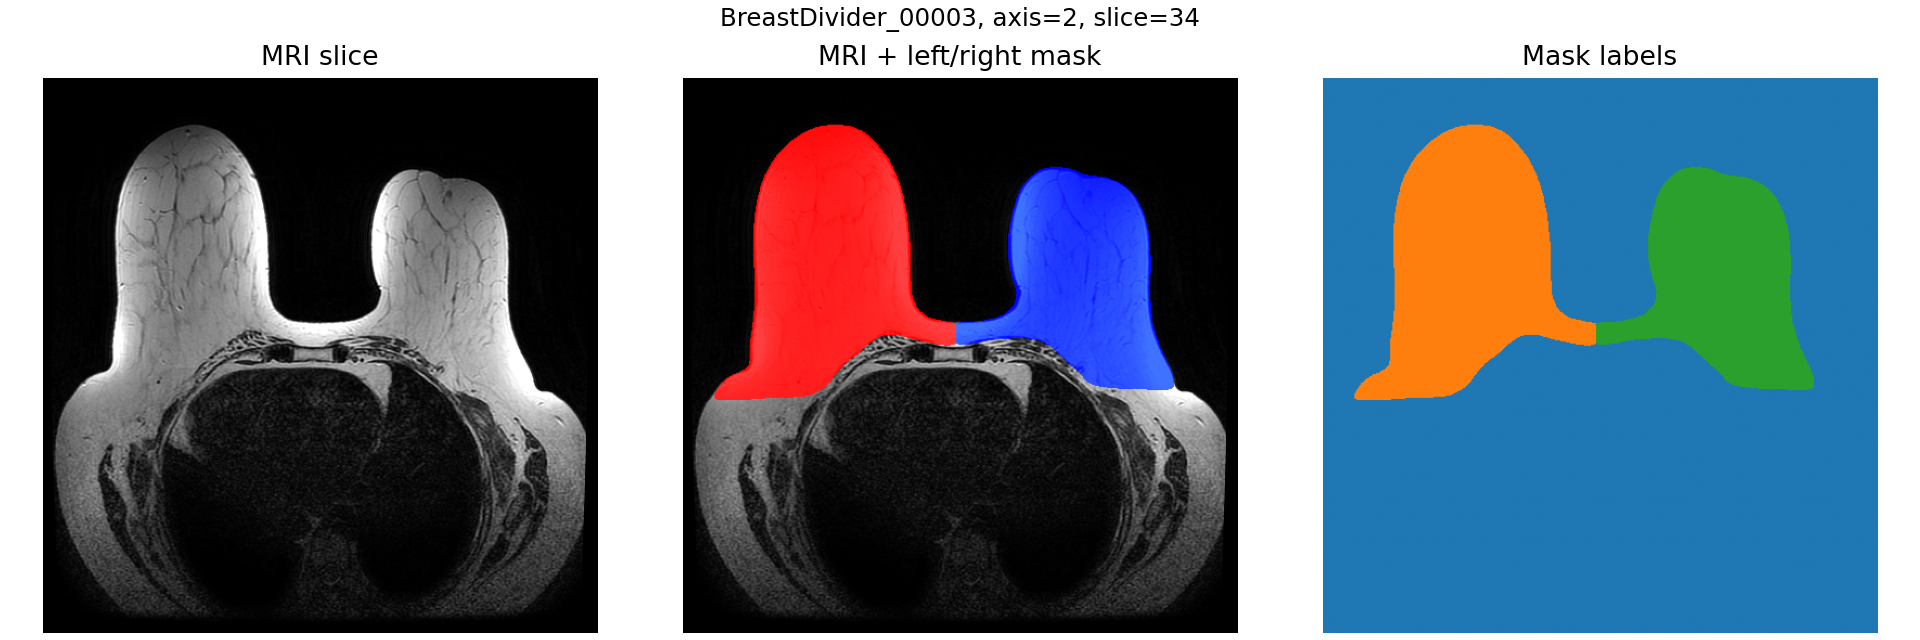

### BreastDivider_00004_overlay.png

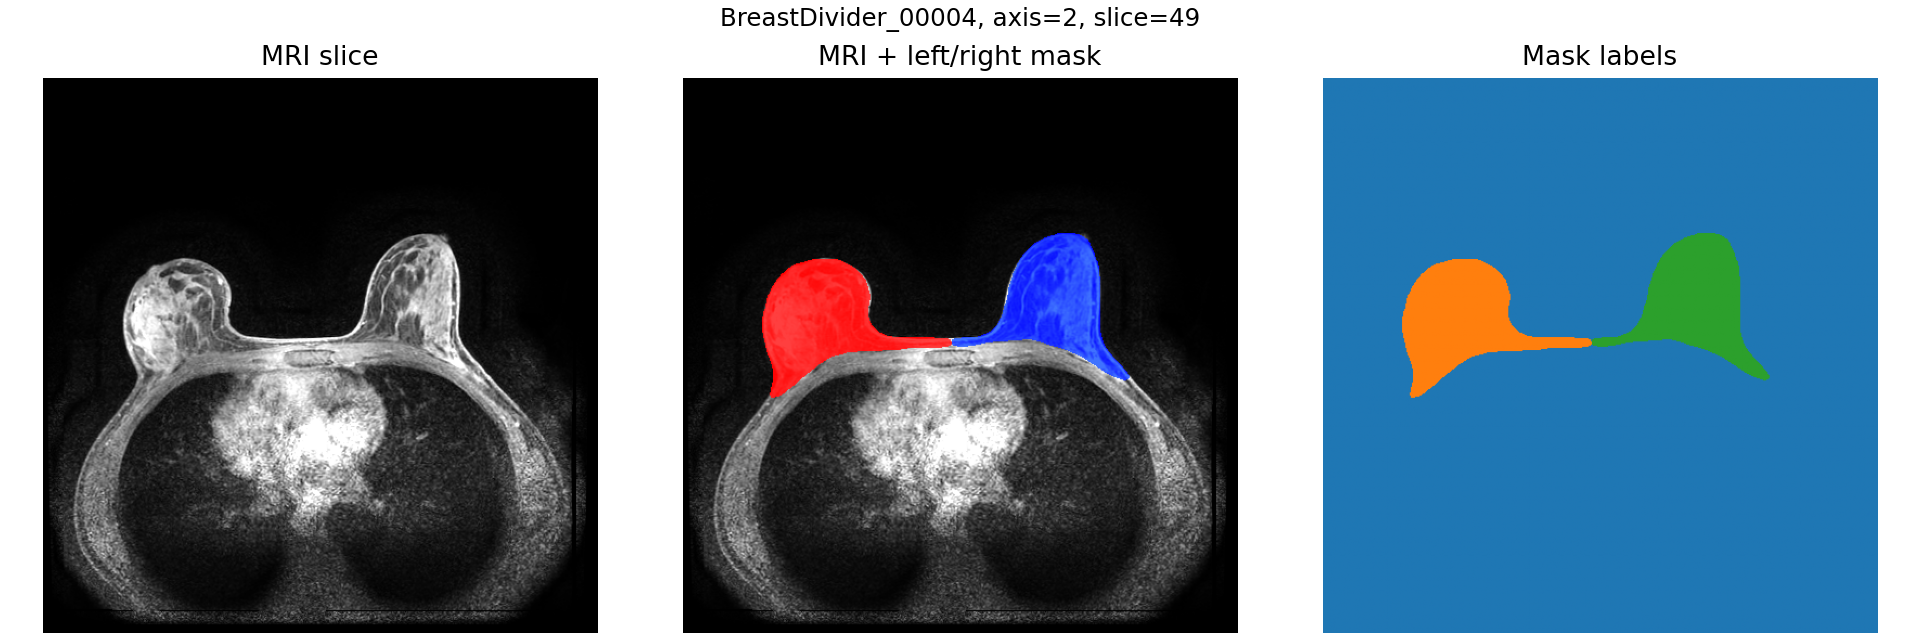

### BreastDivider_00005_overlay.png

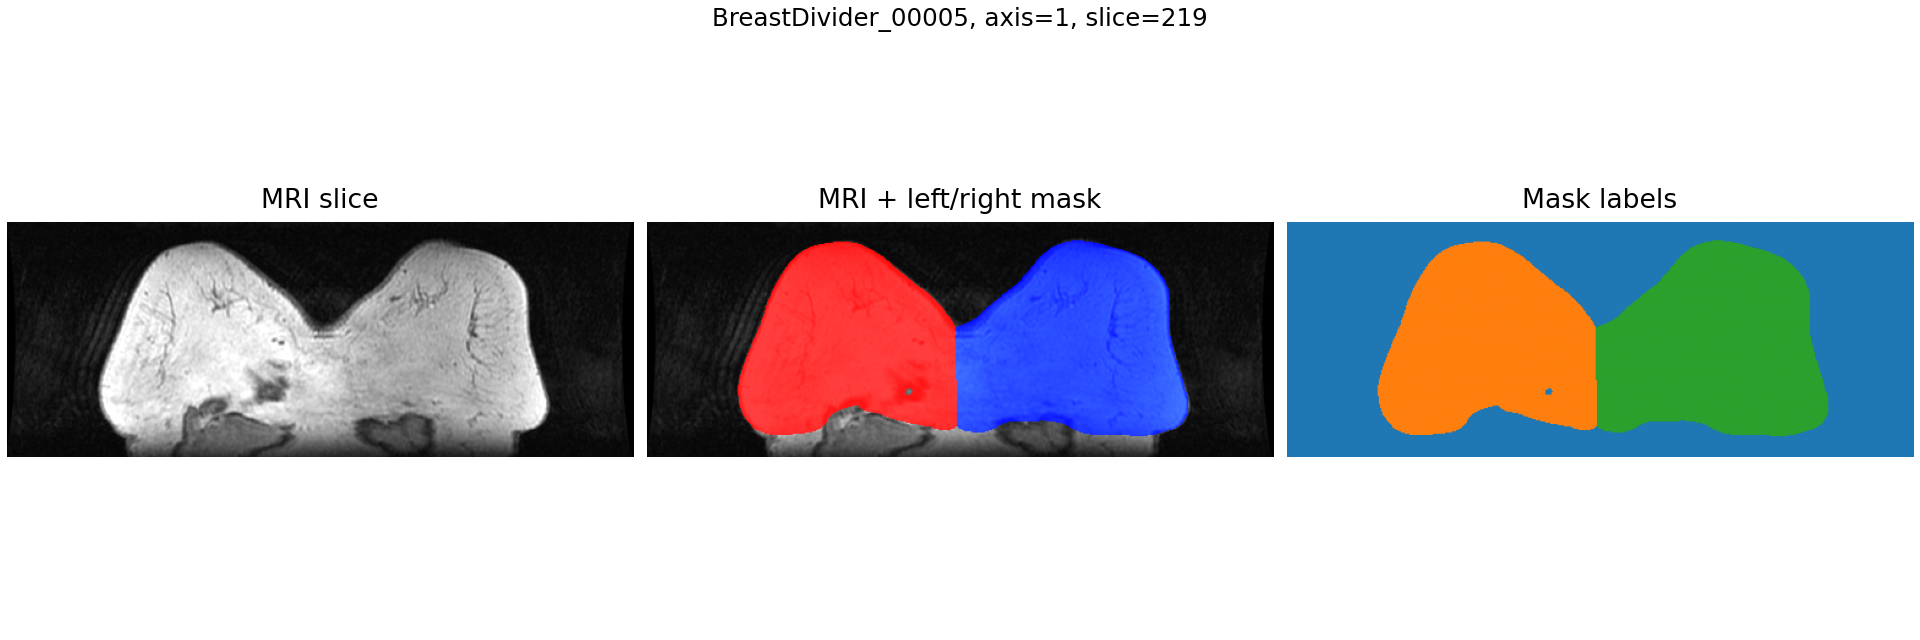

### BreastDivider_00006_overlay.png

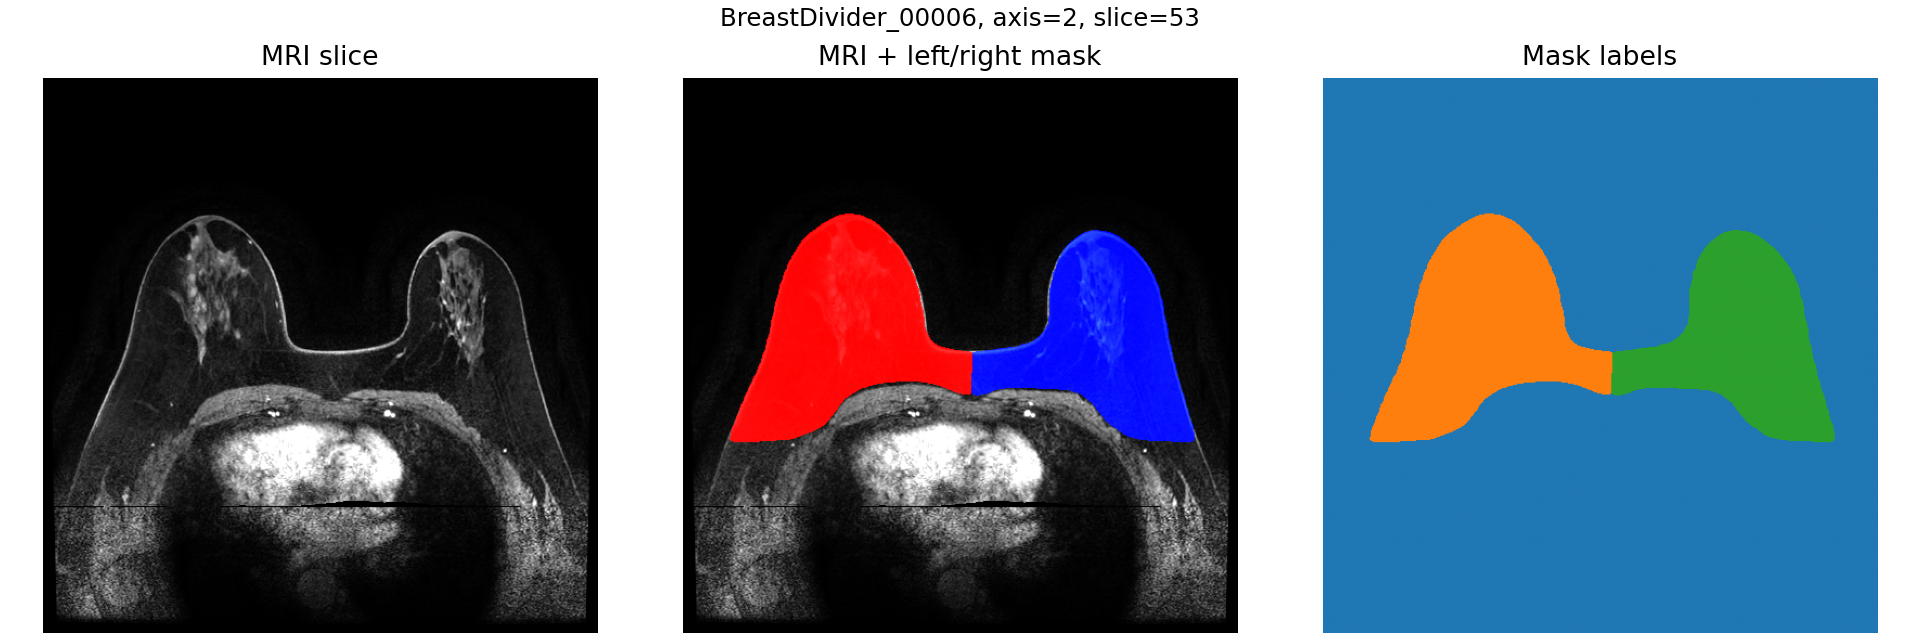

### BreastDivider_00007_overlay.png

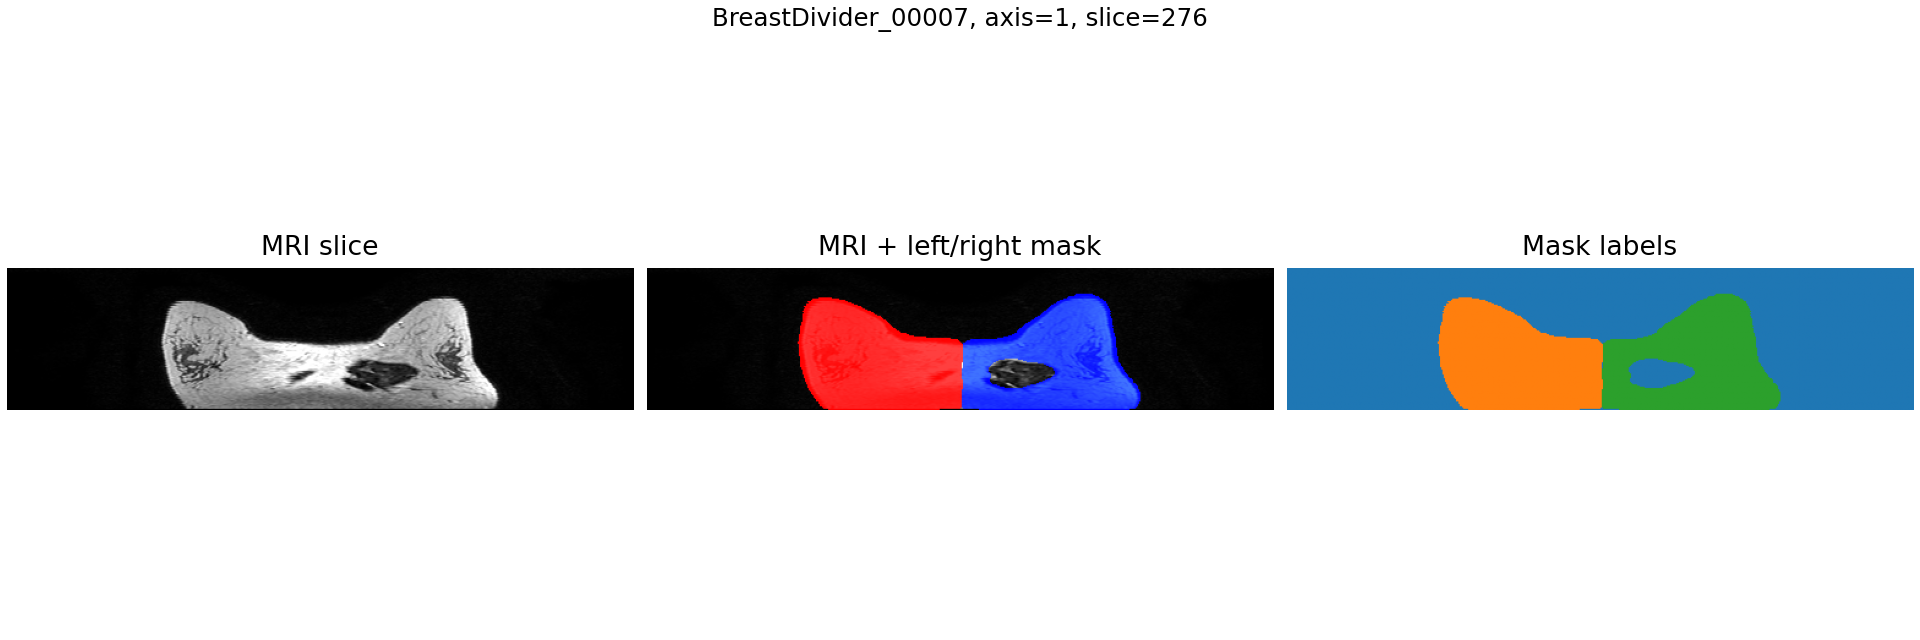

In [9]:
png_paths = sorted(VIS_DIR.glob('*.png'))
print('PNG visualizations:', len(png_paths))

for path in png_paths[:6]:
    display(Markdown(f'### {path.name}'))
    display(Image(filename=str(path)))

## 7. Wnioski z Etapu 1

Podsumowanie oraz wnioski po analzie technicznej datasetu:

1. Udalo sie pobrac metadane BreastDivider oraz mala probke obrazow i masek w formacie `.nii.gz`. Oznacza to, ze dataset jest technicznie dostepny lokalnie i mozna go analizowac standardowymi narzedziami do obrazow medycznych.
2. Pliki NIfTI otwieraja sie poprawnie, a dla sparowanych przypadkow obraz i maska maja zgodne wymiary. To potwierdza, ze podstawowy schemat parowania `image -> mask` dziala i moze byc wykorzystany w dalszym preprocessingu.
3. Maski zawieraja oczekiwane etykiety `0`, `1`, `2`, odpowiadajace tlu oraz lewej i prawej piersi. Taki format etykiet jest prosty do wykorzystania w skryptach: mozna latwo tworzyc maske calej piersi albo osobne maski strony lewej i prawej.
4. Wizualizacje overlay potwierdzaja, ze maski obejmuja anatomicznie sensowne regiony piersi. Jest to wazne, poniewaz w pracy planowany model embeddingowy ma operowac na przekrojach 2D, a maski moga pomoc wybrac tylko te slice'y, ktore zawieraja rzeczywista tkanke piersi.
5. Dataset wykazuje duza zmiennosc shape, spacing, dtype i zakresow intensywnosci. W probce wystepuja m.in. rozmiary `448x448x120`, `512x512x116`, `512x512x192` oraz `480x160x480`, a spacing i typ danych roznia sie miedzy przypadkami. To oznacza, ze preprocessing nie moze zakladac jednego stalego rozmiaru danych.
6. Dalszy pipeline powinien uwzgledniac kontrolowana normalizacje intensywnosci, wybor osi przekrojow, crop lub resize oraz odrzucanie slice'ow z mala powierzchnia maski piersi. Bez tych krokow model moglby uczyc sie roznic technicznych miedzy akwizycjami zamiast cech istotnych dla rekonstrukcji obrazu.
7. BreastDivider nadaje sie do przygotowania pipeline'u slice-level: wyboru przekrojow z tkanka piersi, maskowania/cropowania oraz odrzucania pustych przekrojow. Jest to zgodne z pierwsza faza planowanej pracy, czyli uczeniem modelu embeddingowego na pojedynczych przekrojach 2D MRI piersi.
8. Na podstawie tej probki mozna stwierdzic, ze BreastDivider jest szczegolnie uzyteczny jako dataset anatomiczny i preprocessingowy. Nie jest to jeszcze potwierdzenie, ze dataset samodzielnie wystarczy do trenowania virtual DCE, poniewaz do tego potrzebne sa jednoznaczne pary pre-contrast/post-contrast.
9. Probka techniczna nie wystarcza do wnioskow statystycznych ani trenowania modelu. Jej wartosc polega na walidacji formatu danych, sprawdzeniu parowania obrazow i masek oraz przygotowaniu podstaw do wiekszej analizy datasetu.